<a href="https://colab.research.google.com/github/grarun2001/multiclass_CNN/blob/main/multiclass_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

100%|██████████| 170M/170M [44:13<00:00, 64.3kB/s]


Training images: 50000
Test images: 10000


In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("Number of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, "→", name)

Number of classes: 10
0 → Airplane
1 → Automobile
2 → Bird
3 → Cat
4 → Deer
5 → Dog
6 → Frog
7 → Horse
8 → Ship
9 → Truck


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Training batches: 782
Test batches: 157


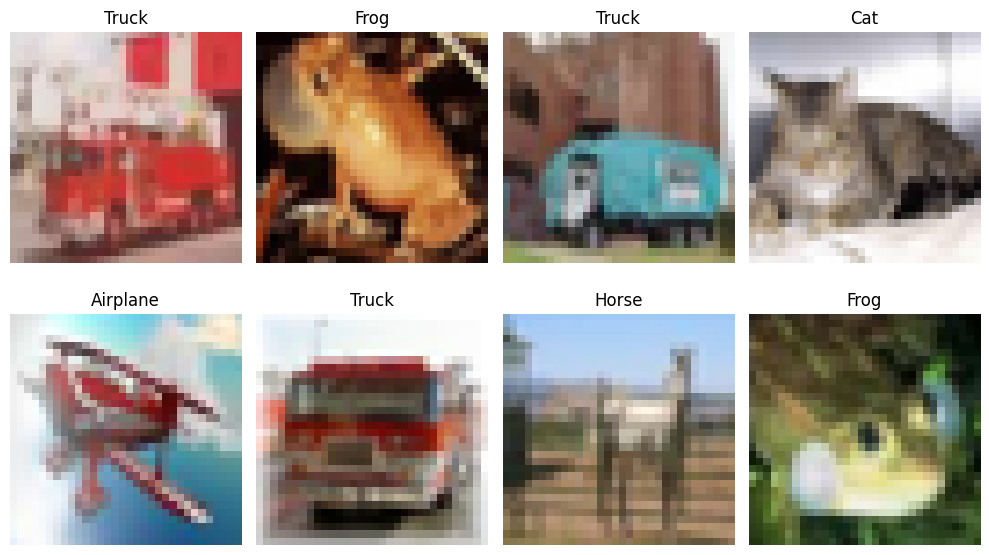

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    image = images[i].permute(1, 2, 0)

    plt.imshow(image)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

CIFAR-10 Training Dataset Distribution
--------------------------------------------------
0 - Airplane     : 5000 images
1 - Automobile   : 5000 images
2 - Bird         : 5000 images
3 - Cat          : 5000 images
4 - Deer         : 5000 images
5 - Dog          : 5000 images
6 - Frog         : 5000 images
7 - Horse        : 5000 images
8 - Ship         : 5000 images
9 - Truck        : 5000 images


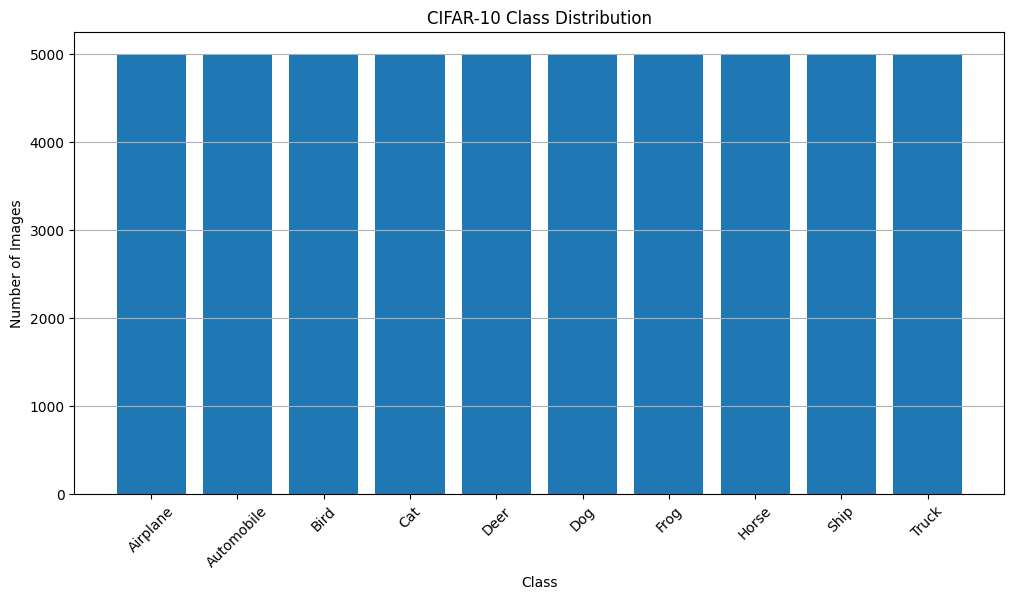

In [ ]:
import numpy as np

class_counts = np.bincount(
    train_dataset.targets,
    minlength=10
)

print("CIFAR-10 Training Dataset Distribution")
print("-" * 50)

for i in range(10):
    print(
        f"{i} - {class_names[i]:12s} : "
        f"{class_counts[i]} images"
    )

plt.figure(figsize=(12, 6))

plt.bar(class_names, class_counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNN().to(device)

print("Device:", device)
print(model)

Device: cuda
CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / len(train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 1.6824 Accuracy: 38.29%
Epoch [2/10] Loss: 1.3232 Accuracy: 52.42%
Epoch [3/10] Loss: 1.1604 Accuracy: 58.52%
Epoch [4/10] Loss: 1.0528 Accuracy: 63.18%
Epoch [5/10] Loss: 0.9755 Accuracy: 65.99%
Epoch [6/10] Loss: 0.9008 Accuracy: 68.36%
Epoch [7/10] Loss: 0.8420 Accuracy: 70.58%
Epoch [8/10] Loss: 0.7967 Accuracy: 72.49%
Epoch [9/10] Loss: 0.7509 Accuracy: 73.84%
Epoch [10/10] Loss: 0.7106 Accuracy: 75.25%


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

test_accuracy = 100 * correct / total

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 73.21%


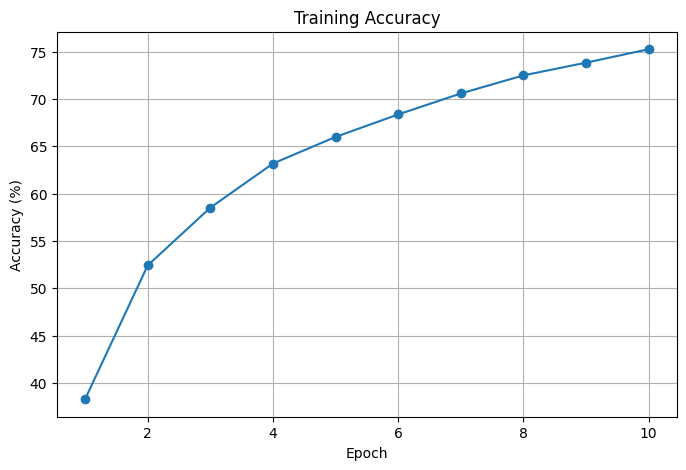

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.grid()
plt.show()

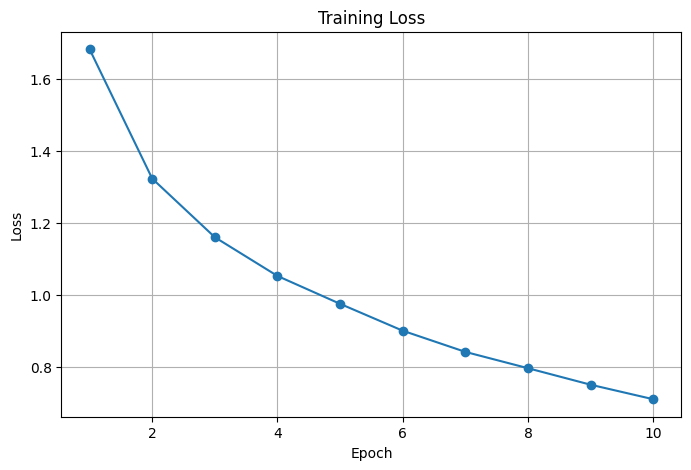

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid()
plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "cifar10_multiclass_cnn.pth"
)

print("Model saved successfully!")

Model saved successfully!


Saving Frog.jpeg to Frog.jpeg
Selected image: Frog.jpeg


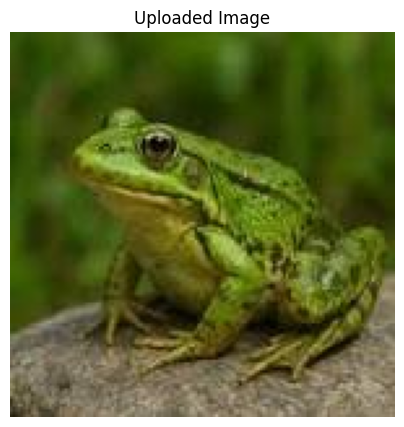

Input shape: torch.Size([1, 3, 32, 32])
Predicted Class: Frog
Confidence: 95.70%


In [ ]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

image_name = list(uploaded.keys())[0]

image = Image.open(image_name).convert("RGB")

print("Selected image:", image_name)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()


# Same preprocessing used by the model
prediction_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

image_tensor = prediction_transform(image)

image_tensor = image_tensor.unsqueeze(0).to(device)


# Prediction
model.eval()

with torch.no_grad():

    outputs = model(image_tensor)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predicted_index = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[
        0,
        predicted_index
    ].item()


predicted_class = class_names[predicted_index]

print("Input shape:", image_tensor.shape)
print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")